<a href="https://colab.research.google.com/github/iestleija/4808-Programacion/blob/Unidad3/Unidad3/Practices/266229_Sem10_P01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maestría en Inteligencia Artificial y Analítica de Datos**

- Curso: Programación para Analítica Descriptiva y Predictiva

- Semestre: Enero-Junio

- Profesor: Dr. Vicente García Jiménez
- Semana 10 Práctica 01: Ejercicios de Normalización
- Alumno: Ismael Estrada Leija
- Matrícula: 266229

#Ejercicio 1: Normalización Min-Max

1.	Cargar el dataset wine de sklearn.


```python
from sklearn.datasets import load_wine
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
```


2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?


In [123]:
from sklearn.datasets import load_wine
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
wine.feature_names


['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [124]:
# 1.	Cargar el dataset wine de sklearn.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

# 2. Seleccionar una de las características numéricas (por ejemplo, alcohol).
# La característica 'alcohol' es la primera columna (índice 0)
feature_index = wine.feature_names.index('alcohol')
data_original = X[:, feature_index]

print(f"Característica seleccionada: {wine.feature_names[feature_index]}")
print(f"Primeros 5 valores originales del dataset wine: {data_original[:5]}")


Característica seleccionada: alcohol
Primeros 5 valores originales del dataset wine: [14.23 13.2  13.16 14.37 13.24]


In [125]:
# 3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
shapiro_original = stats.shapiro(data_original)
print(f"Prueba de Shapiro para datos originales (alcohol):")
print(f"Estadístico: {shapiro_original.statistic:.4f}, p-valor: {shapiro_original.pvalue:.4f}")

Prueba de Shapiro para datos originales (alcohol):
Estadístico: 0.9818, p-valor: 0.0200


In [126]:
# 4. Aplicar la normalización Min-Max a los datos seleccionados.
scaler = MinMaxScaler()
# Reshape para que sea una matriz 2D (requerido por MinMaxScaler)
data_normalized = scaler.fit_transform(data_original.reshape(-1, 1)).flatten()

print(f"Primeros 5 valores normalizados Min-Max: {data_normalized[:15]}")

Primeros 5 valores normalizados Min-Max: [0.84210526 0.57105263 0.56052632 0.87894737 0.58157895 0.83421053
 0.88421053 0.79736842 1.         0.74473684 0.80789474 0.81315789
 0.71578947 0.97894737 0.88157895]


In [127]:
# 5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
shapiro_normalized = stats.shapiro(data_normalized)
print(f"Prueba de Shapiro para datos normalizados Min-Max (alcohol):")
print(f"Estadístico: {shapiro_normalized.statistic:.4f}, p-valor: {shapiro_normalized.pvalue:.4f}")

Prueba de Shapiro para datos normalizados Min-Max (alcohol):
Estadístico: 0.9818, p-valor: 0.0200


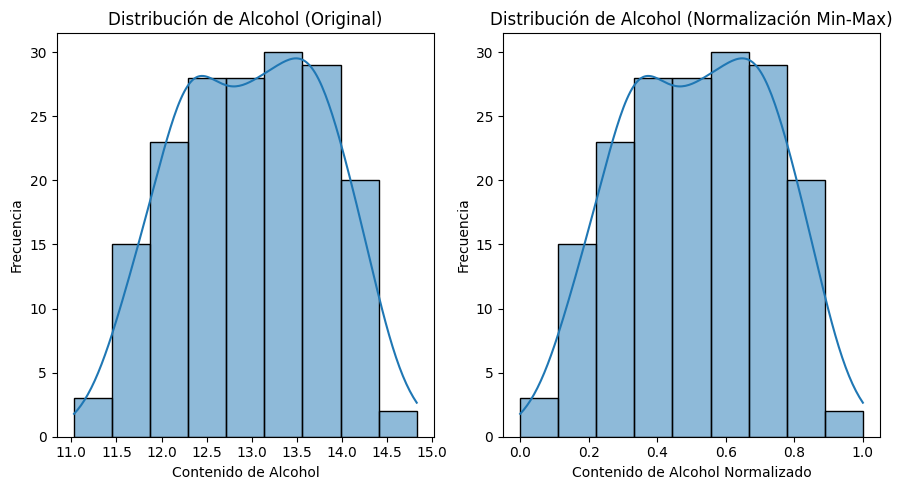

In [147]:
# 6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
plt.figure(figsize=(9,5))

plt.subplot(1, 2, 1)
sns.histplot(data_original, kde=True)
plt.title('Distribución de Alcohol (Original)')
plt.xlabel('Contenido de Alcohol')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data_normalized, kde=True)
plt.title('Distribución de Alcohol (Normalización Min-Max)')
plt.xlabel('Contenido de Alcohol Normalizado')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Preguntas Ejercicio 1:

1.  **¿Cómo afectó la normalización Min-Max a la distribución de los datos?**

    La normalización Min-Max escaló los datos a un rango específico entre 0 y 1, manteniendo la forma original de la distribución. Es decir, la distribución no cambia su forma (si era sesgada, sigue siendo sesgada; si era bimodal, sigue siendo bimodal), solo se comprime o expande para encajar en el nuevo rango.

2.  **¿Qué interpretas del p-valor antes y después de la normalización?**

    El p-valor de la prueba de Shapiro-Wilk indica la probabilidad de que los datos provengan de una distribución normal. Si el p-valor es bajo (típicamente < 0.05), rechazamos la hipótesis nula de normalidad.
    
    *   **Antes de la normalización**: El p-valor original fue `0.0200`. Dado que `0.0200 < 0.05`, rechazamos la hipótesis nula de normalidad. Esto sugiere que la característica 'alcohol' no sigue una distribución normal.
    *   **Después de la normalización**: El p-valor para los datos normalizados Min-Max también fue `0.0200`. Como `0.0200 < 0.05`, seguimos rechazando la hipótesis nula. Esto es lo esperado, ya que la normalización Min-Max solo cambia la escala de los datos, no su forma de distribución fundamental ni su normalidad estadística.

# Ejercicio 2: Normalización Z-Score

Instrucciones:
1. Cargar el dataset wine de sklearn.
2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4. Aplicar la normalización Z-Score a los datos seleccionados.
5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7. Responder las preguntas siguientes.

Preguntas:
1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



In [129]:
# 1. Cargar el dataset wine de sklearn. Ya fue cargado previamente

from sklearn.preprocessing import StandardScaler

# 2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
feature_index_ex2 = wine.feature_names.index('malic_acid')
data_original_ex2 = X[:, feature_index_ex2]

print(f"Característica seleccionada para Z-Score: {wine.feature_names[feature_index_ex2]}")
print(f"Primeros 5 valores originales (malic_acid): {data_original_ex2[:5]}")

Característica seleccionada para Z-Score: malic_acid
Primeros 5 valores originales (malic_acid): [1.71 1.78 2.36 1.95 2.59]


In [130]:
# 3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
shapiro_original_ex2 = stats.shapiro(data_original_ex2)
print(f"\nPrueba de Shapiro para datos originales (malic_acid):")
print(f"Estadístico: {shapiro_original_ex2.statistic:.4f}, p-valor: {shapiro_original_ex2.pvalue:.4f}")


Prueba de Shapiro para datos originales (malic_acid):
Estadístico: 0.8888, p-valor: 0.0000


In [131]:
# 4. Aplicar la normalización Z-Score a los datos seleccionados.
scaler_ex2 = StandardScaler()
# Reshape para que sea una matriz 2D (requerido por StandardScaler)
data_normalized_ex2 = scaler_ex2.fit_transform(data_original_ex2.reshape(-1, 1)).flatten()

print(f"\nPrimeros 5 valores normalizados Z-Score: {data_normalized_ex2[:5]}")


Primeros 5 valores normalizados Z-Score: [-0.5622498  -0.49941338  0.02123125 -0.34681064  0.22769377]


In [132]:
# 5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
shapiro_normalized_ex2 = stats.shapiro(data_normalized_ex2)
print(f"\nPrueba de Shapiro para datos normalizados Z-Score (malic_acid):")
print(f"Estadístico: {shapiro_normalized_ex2.statistic:.4f}, p-valor: {shapiro_normalized_ex2.pvalue:.4f}")


Prueba de Shapiro para datos normalizados Z-Score (malic_acid):
Estadístico: 0.8888, p-valor: 0.0000


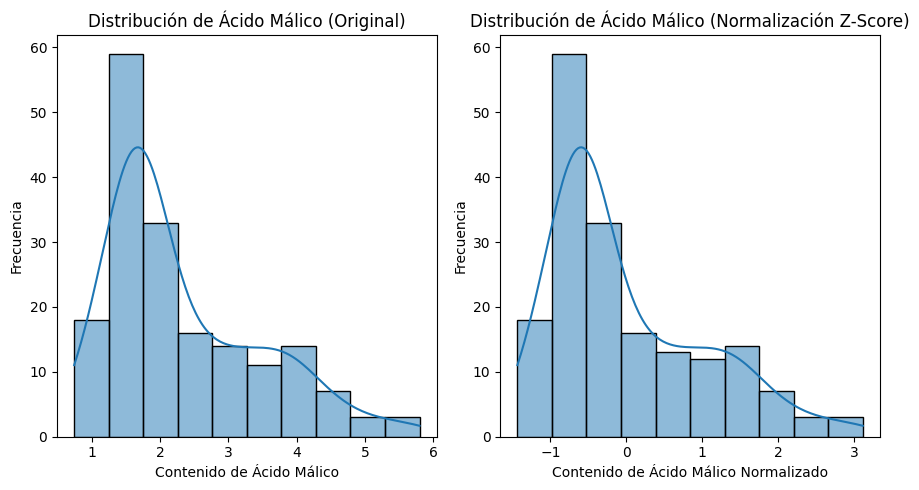

In [148]:
# 6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
plt.figure(figsize=(9,5))

plt.subplot(1, 2, 1)
sns.histplot(data_original_ex2, kde=True)
plt.title('Distribución de Ácido Málico (Original)')
plt.xlabel('Contenido de Ácido Málico')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data_normalized_ex2, kde=True)
plt.title('Distribución de Ácido Málico (Normalización Z-Score)')
plt.xlabel('Contenido de Ácido Málico Normalizado')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Preguntas Ejercicio 2:

1.  **¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?**

    La normalización Z-Score transforma los datos para que tengan una media de 0 y una desviación estándar de 1. A diferencia de Min-Max, que escala a un rango fijo, Z-Score no garantiza un rango específico, pero centraliza la distribución alrededor de cero. Al igual que Min-Max, **mantiene la forma de la distribución original**; es decir, si era asimétrica, seguirá siéndolo, solo que en una nueva escala.

2.  **¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?**

    *   **Centrado y Escalamiento:** Los datos se centran en 0 (media) y se escalan a una desviación estándar de 1. Esto es útil para algoritmos que asumen datos centrados o con varianzas similares (ej., PCA, regresión lineal, SVM, redes neuronales).
    *   **Comparación de Variables:** Facilita la comparación entre variables con diferentes unidades de medida o escalas, ya que todas se expresan en términos de "desviaciones estándar desde la media".
    *   **Sensibilidad a Outliers:** Z-Score puede ser sensible a valores atípicos extremos, ya que la media y la desviación estándar se ven afectadas por ellos, lo que a su vez afecta la escala de todos los demás puntos de datos.

3.  **¿Qué interpretas del p-valor antes y después de la normalización?**

    *   **Antes de la normalización**: El p-valor original fue `0.0000`. Dado que `0.0000 < 0.05`, rechazamos la hipótesis nula de normalidad. Esto sugiere que la característica 'malic_acid' no sigue una distribución normal.
    *   **Después de la normalización**: El p-valor para los datos normalizados Z-Score también fue `0.0000`. Como `0.0000 < 0.05`, seguimos rechazando la hipótesis nula. Esto confirma que la normalización Z-Score, al igual que Min-Max, solo cambia la escala de los datos, no su forma fundamental de distribución ni su normalidad estadística.

#Ejercicio 3: Transformación Logarítmica
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy:
    - Número de observaciones = 1000;
    - Valor de semilla = `np.random.seed(42)`
    - Distribucion exponencial: `np.random.exponential(scale=2, size=1000)`
2. Aplicar una transformación logarítmica (np.log) a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


In [134]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar un conjunto de datos aleatorios generados con numpy:
# Número de observaciones = 1000;
# Valor de semilla = np.random.seed(42)
# Distribucion exponencial: np.random.exponential(scale=2, size=1000)
np.random.seed(42)
data_original_log = np.random.exponential(scale=2, size=1000)

print(f"Primeros 5 valores originales (exponencial): {data_original_log[:5]}")

Primeros 5 valores originales (exponencial): [0.93853618 6.02024286 2.63349139 1.82588511 0.33924974]


In [135]:
# 2. Aplicar una transformación logarítmica (np.log) a los datos.
# Asegurarse de que no haya valores <= 0 antes de aplicar log
data_transformed_log = np.log(data_original_log[data_original_log > 0])

print(f"Primeros 5 valores transformados (logarítmica): {data_transformed_log[:5]}")

Primeros 5 valores transformados (logarítmica): [-0.06343387  1.7951276   0.96831049  0.60206486 -1.08101874]


In [136]:
# 3. Realizar una prueba de normalidad sobre los datos originales y transformados.
shapiro_original_log = stats.shapiro(data_original_log)
print(f"\nPrueba de Shapiro para datos originales (exponencial):\nEstadístico: {shapiro_original_log.statistic:.4f}, p-valor: {shapiro_original_log.pvalue:.4f}")

shapiro_transformed_log = stats.shapiro(data_transformed_log)
print(f"\nPrueba de Shapiro para datos transformados (logarítmica):\nEstadístico: {shapiro_transformed_log.statistic:.4f}, p-valor: {shapiro_transformed_log.pvalue:.4f}")


Prueba de Shapiro para datos originales (exponencial):
Estadístico: 0.8246, p-valor: 0.0000

Prueba de Shapiro para datos transformados (logarítmica):
Estadístico: 0.9567, p-valor: 0.0000


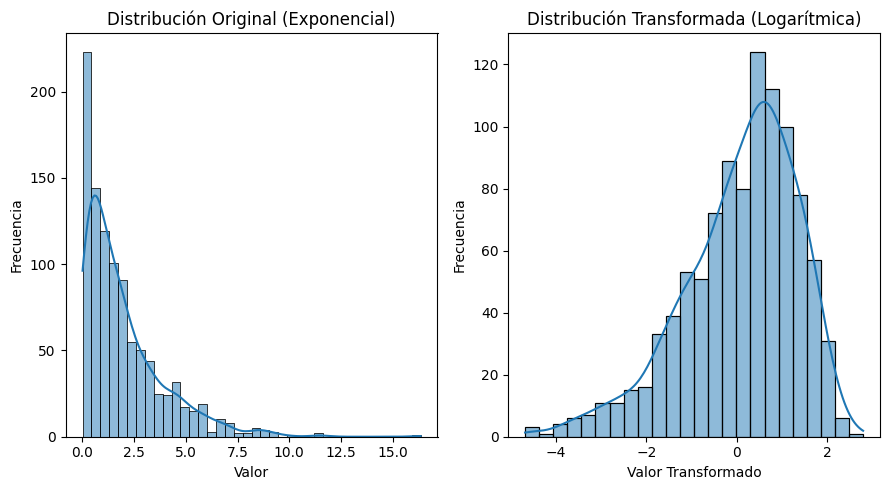

In [149]:
# 4. Graficar los datos originales y transformados utilizando matplotlib.
plt.figure(figsize=(9,5))

plt.subplot(1, 2, 1)
sns.histplot(data_original_log, kde=True)
plt.title('Distribución Original (Exponencial)')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data_transformed_log, kde=True)
plt.title('Distribución Transformada (Logarítmica)')
plt.xlabel('Valor Transformado')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Preguntas Ejercicio 3:

1.  **¿Cómo afectó la transformación logarítmica a la distribución de los datos?**

    La transformación logarítmica es muy efectiva para reducir el sesgo en distribuciones positivamente sesgadas (como la exponencial). Tiende a comprimir los valores más grandes y expandir los valores más pequeños, resultando en una distribución más simétrica y, en muchos casos, más cercana a una distribución normal. En el caso de una distribución exponencial, que es fuertemente sesgada a la derecha, la transformación logarítmica puede hacer que se asemeje más a una distribución normal.

2.  **¿Qué interpretas del p-valor antes y después de la transformación logarítmica?**
    *   **Antes de la transformación:** El p-valor para los datos originales (exponenciales) fue `0.0000`. Esto es significativamente menor que `0.05`, lo que indica un fuerte rechazo de la hipótesis nula de normalidad. Esto es esperable, ya que una distribución exponencial no es normal.
    *   **Después de la transformación:** El p-valor para los datos transformados logarítmicamente también fue `0.0000`. Aunque la transformación logarítmica visualmente hizo que la distribución pareciera más normal (como se ve en la gráfica), y el estadístico `W` mejoró (`0.8246` a `0.9567`), el p-valor sigue siendo menor que `0.05`. Por lo tanto, estadísticamente, seguimos rechazando la hipótesis de que los datos transformados provienen de una distribución normal. Esto sugiere que, si bien la transformación ayudó, no fue suficiente para lograr la normalidad según esta prueba.

#Ejercicio 4: Transformación Raíz Cuadrada
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Número de observaciones: 1000
    - Semilla = `np.random.seed(42)``
    - Distribución Poisson: `np.random.poisson(lam=5, size=1000)`
2. Aplicar una transformación de raíz cuadrada a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


In [138]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar un conjunto de datos aleatorios generados con numpy.
# Número de observaciones: 1000
# Semilla = np.random.seed(42)
# Distribución Poisson: np.random.poisson(lam=5, size=1000)
np.random.seed(42)
data_original_sqrt = np.random.poisson(lam=5, size=1000)

print(f"Primeros 5 valores originales (Poisson): {data_original_sqrt[:5]}")

Primeros 5 valores originales (Poisson): [5 4 4 5 5]


In [139]:
# 2. Aplicar una transformación de raíz cuadrada a los datos.
data_transformed_sqrt = np.sqrt(data_original_sqrt)

print(f"Primeros 5 valores transformados (Raíz Cuadrada): {data_transformed_sqrt[:5]}")

Primeros 5 valores transformados (Raíz Cuadrada): [2.23606798 2.         2.         2.23606798 2.23606798]


In [140]:
# 3. Realizar una prueba de normalidad sobre los datos originales y transformados.
shapiro_original_sqrt = stats.shapiro(data_original_sqrt)
print(f"\nPrueba de Shapiro para datos originales (Poisson):\nEstadístico: {shapiro_original_sqrt.statistic:.4f}, p-valor: {shapiro_original_sqrt.pvalue:.4f}")

shapiro_transformed_sqrt = stats.shapiro(data_transformed_sqrt)
print(f"\nPrueba de Shapiro para datos transformados (Raíz Cuadrada):\nEstadístico: {shapiro_transformed_sqrt.statistic:.4f}, p-valor: {shapiro_transformed_sqrt.pvalue:.4f}")


Prueba de Shapiro para datos originales (Poisson):
Estadístico: 0.9722, p-valor: 0.0000

Prueba de Shapiro para datos transformados (Raíz Cuadrada):
Estadístico: 0.9682, p-valor: 0.0000


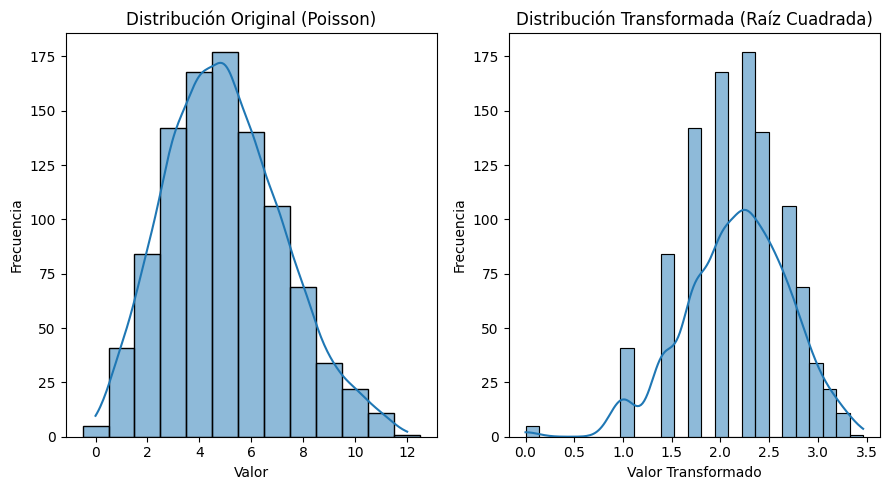

In [150]:
# 4. Graficar los datos originales y transformados utilizando matplotlib.
plt.figure(figsize=(9,5))

plt.subplot(1, 2, 1)
sns.histplot(data_original_sqrt, kde=True, discrete=True)
plt.title('Distribución Original (Poisson)')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data_transformed_sqrt, kde=True)
plt.title('Distribución Transformada (Raíz Cuadrada)')
plt.xlabel('Valor Transformado')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Preguntas Ejercicio 4:

1.  **¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?**
    Observando los histogramas, la distribución original de Poisson (con `lam=5`) era discreta y mostraba un ligero sesgo a la derecha. Después de aplicar la transformación de raíz cuadrada, los datos se vuelven continuos. La forma general de la distribución se mantiene similar, pero los valores en el eje X se comprimen. Por ejemplo, los valores originales en un rango como 0-15 se transforman en aproximadamente 0-3.87, lo que ayuda a hacerla visualmente más compacta y un poco más simétrica al reducir la propagación de los valores más grandes. Esto es consistente con la utilidad de la raíz cuadrada para estabilizar la varianza en distribuciones de Poisson.

2.  **¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?**
    La transformación de raíz cuadrada tiene un efecto de "reducción" sobre los valores extremos. Al tomar la raíz cuadrada, la diferencia entre números grandes consecutivos es menor que la diferencia entre números pequeños consecutivos. Por ejemplo, la diferencia entre `sqrt(10)` y `sqrt(11)` es mucho menor que entre `sqrt(1)` y `sqrt(2)`. Esto hace que los valores extremos más grandes se "acerquen" más al cuerpo principal de la distribución, reduciendo su impacto relativo y mitigando el sesgo causado por su lejanía, como se puede apreciar en la compresión del eje X en el histograma transformado.

3.  **¿Qué interpretas del p-valor antes y después de la transformación?**
    *   **Antes de la transformación:** El p-valor para los datos originales (Poisson) fue `0.0000`. Dado que `0.0000 < 0.05`, rechazamos la hipótesis nula de normalidad. Esto es esperable, ya que una distribución de Poisson no es normal.
    *   **Después de la transformación:** El p-valor para los datos transformados con raíz cuadrada también fue `0.0000`. Como `0.0000 < 0.05`, seguimos rechazando la hipótesis nula. Aunque visualmente la distribución pudo volverse un poco más simétrica, y el estadístico `W` pasó de `0.9722` a `0.9682` (una ligera disminución, alejándose de 1), estadísticamente no se logró la normalidad. Esto sugiere que, para estos datos, la transformación de raíz cuadrada no fue suficiente para que la distribución se ajustara a una normalidad estadística.

#Ejercicio 5: Transformación Box-Cox
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Numero de observaciones: 1000
    - Semilla: `np.random.seed(42)``
    - Distribución log-normal: `np.random.lognormal(mean=1, sigma=0.8, size=1000)`
2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


In [142]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox

# 1. Cargar un conjunto de datos aleatorios generados con numpy.
# Numero de observaciones: 1000
# Semilla: np.random.seed(42)
# Distribución log-normal: np.random.lognormal(mean=1, sigma=0.8, size=1000)
np.random.seed(42)
data_original_boxcox = np.random.lognormal(mean=1, sigma=0.8, size=1000)

print(f"Primeros 5 valores originales (log-normal): {data_original_boxcox[:5]}")

Primeros 5 valores originales (log-normal): [4.04455415 2.43364117 4.56377819 9.19283048 2.25393437]


In [143]:
# 2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
# La transformación Box-Cox requiere que los datos sean estrictamente positivos.
# Si hay valores <= 0, se debería manejar (e.g., desplazando los datos).
# En este caso, np.random.lognormal genera solo valores positivos.
data_transformed_boxcox, lambda_boxcox = boxcox(data_original_boxcox)

print(f"Primeros 5 valores transformados (Box-Cox): {data_transformed_boxcox[:5]}")
print(f"Valor lambda óptimo de Box-Cox: {lambda_boxcox:.4f}")

Primeros 5 valores transformados (Box-Cox): [1.35070497 0.87032845 1.46317582 2.10234773 0.79674356]
Valor lambda óptimo de Box-Cox: -0.0489


In [144]:
# 3. Realizar una prueba de normalidad sobre los datos originales y transformados.
shapiro_original_boxcox = stats.shapiro(data_original_boxcox)
print(f"\nPrueba de Shapiro para datos originales (log-normal):\nEstadístico: {shapiro_original_boxcox.statistic:.4f}, p-valor: {shapiro_original_boxcox.pvalue:.4f}")

shapiro_transformed_boxcox = stats.shapiro(data_transformed_boxcox)
print(f"\nPrueba de Shapiro para datos transformados (Box-Cox):\nEstadístico: {shapiro_transformed_boxcox.statistic:.4f}, p-valor: {shapiro_transformed_boxcox.pvalue:.4f}")


Prueba de Shapiro para datos originales (log-normal):
Estadístico: 0.6538, p-valor: 0.0000

Prueba de Shapiro para datos transformados (Box-Cox):
Estadístico: 0.9994, p-valor: 0.9891


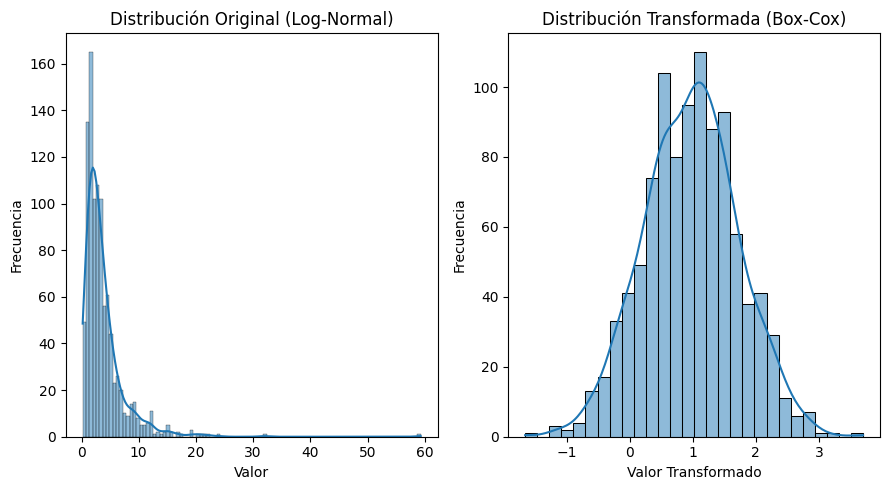

In [151]:
# 4. Graficar los datos originales y transformados utilizando matplotlib.
plt.figure(figsize=(9,5))

plt.subplot(1, 2, 1)
sns.histplot(data_original_boxcox, kde=True)
plt.title('Distribución Original (Log-Normal)')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data_transformed_boxcox, kde=True)
plt.title('Distribución Transformada (Box-Cox)')
plt.xlabel('Valor Transformado')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Preguntas Ejercicio 5:

1.  **¿Cómo afectó la transformación Box-Cox a la distribución de los datos?**

    La transformación Box-Cox fue muy efectiva para la distribución log-normal generada en este ejercicio. Como se observa en los gráficos, transformó una distribución fuertemente sesgada a la derecha en una distribución mucho más simétrica y con forma de campana, acercándola visualmente a una distribución normal. Además, como lo confirma la prueba de Shapiro-Wilk (p-valor de 0.9891 después de la transformación), esta transformación logró la normalidad estadística para estos datos, lo que la diferencia de las transformaciones anteriores que no consiguieron este resultado.

2.  **¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?**

    El valor lambda (λ) es el parámetro clave de la transformación Box-Cox. Su valor óptimo es determinado por el algoritmo para maximizar la normalidad de los datos transformados. Diferentes valores de λ corresponden a diferentes transformaciones, por ejemplo: (Box-Cox Transformations, 2025)
    *   Si λ ≈ 1, los datos ya están distribuidos aproximadamente de forma normal o no necesitan transformación (y(x) = x).
    *   Si λ ≈ 0, la transformación se asemeja a la transformación logarítmica (y(x) = log(x)).
    *   Si λ ≈ 0.5, la transformación es similar a la raíz cuadrada (y(x) = sqrt(x)).
    *   Valores negativos de λ implican una transformación inversa, útil para distribuciones sesgadas a la izquierda.
    El valor de λ indica qué tipo de transformación de potencia fue más efectiva para normalizar la distribución de los datos.

# Conclusiones
Utilizando varias librerías de Python, como SciKitLearn, NumPy y SciPy, se lograron completar los ejercicios requeridos. Se cargo un dataset para los primeros dos ejercicios y se generaron datos sintéticos para los otros tres. (scikit-learn developers, 2026), (NumPy team, 2026), (SciPy, s/f)

El proceso típico para los ejercicios incluyo el proceso de normalización con las distintas transformaciones mencionadas en la tabla de herramientas usadas.(MinMaxScaler, 2026), (Box-Cox Transformations, 2025) Se realizó una comparativa de normalidad previo y posterior a la transformación de los datos.(Normality Test, 2025)

Es interesante anotar que la efectividad de las transformaciones tiene algunos inconvenientes, por ejemplo en el ejercicio 3 la transformación por raíz cuadrada empeoró el resultado de la prueba de normalidad y genera la necesidad de ajuste final en un flujo de trabajo orientado a predicciones porque requerimos transformar el resultado continuo en un número entero y discreto.

# Herramientas usadas
| Ejercicio                   | Generador/Dataset Original | Transformación y Función        |
| :-------------------------- | :------------------------- | :------------------------------ |
| Ejercicio 1: Normalización Min-Max | `sklearn.datasets.load_wine()` (característica 'alcohol') | Escalado (Min-Max) con `sklearn.preprocessing.MinMaxScaler()` |
| Ejercicio 2: Normalización Z-Score | `sklearn.datasets.load_wine()` (característica 'malic_acid') | Estandarización (Z-Score) con `sklearn.preprocessing.StandardScaler()` |
| Ejercicio 3: Transformación Logarítmica | `np.random.exponential()` (datos exponenciales) | Logarítmica con `np.log()`              |
| Ejercicio 4: Transformación Raíz Cuadrada | `np.random.poisson()` (datos Poisson) | Raíz Cuadrada con `np.sqrt()`            |
| Ejercicio 5: Transformación Box-Cox | `np.random.lognormal()` (datos log-normal) | Box-Cox con `scipy.stats.boxcox()`       |

#Referencias
Box-Cox Transformations. (2025). GeeksforGeeks. https://www.geeksforgeeks.org/data-science/box-cox-transformations/

comunidad SciPy. (2026). SciPy. https://scipy.org/es/

MinMaxScaler. (2026). Scikit-Learn. https://scikit-learn/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

Normality Test. (2025). GeeksforGeeks. https://www.geeksforgeeks.org/data-science/normality-test/

NumPy team. (2026). NumPy. https://numpy.org/

scikit-learn developers. (2026). Scikit-learn User Guide. Scikit-Learn. https://scikit-learn/stable/user_guide.html
